<a href="https://colab.research.google.com/github/omololaeni/my-data-analysis-for-my-research-project-/blob/main/Online_Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Historical Sales Data to Identify Sales Trends for Data-Driven Decision-Making

**Researcher:** Omolola Alao

**Dataset:** UCI Online Retail Dataset

**Programme:** DataRaFlow Cohort 2

## 1. Introduction

Sales data plays an important role in helping businesses understand their performance and make informed decisions. By analyzing historical sales records, businesses can identify trends, recognize products that contribute more to sales, and understand how sales performance varies across different periods and markets.

This project analyzes the Online Retail dataset obtained from the UCI Machine Learning Repository. The dataset contains transaction records from a UK-based online retailer covering December 2010 to December 2011.

The study focuses on monthly sales trends, product sales performance, and sales across different countries. The aim is to use data analysis to identify useful patterns that can support data-driven business decision-making.

## 2. Dataset Description

The dataset used in this study is the Online Retail dataset obtained from the UCI Machine Learning Repository. It contains historical transactions from a UK-based online retailer between December 2010 and December 2011.

The original dataset contains 541,909 records and eight columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. These columns provide information about transactions, products, quantities purchased, dates, prices, customers, and countries.

The dataset was selected because it contains historical transaction records suitable for analyzing sales trends, product performance, and sales across different countries.

## 3. Problem Statement

Businesses generate large amounts of sales data, but the data needs to be analyzed to understand sales performance and identify useful patterns. Without proper analysis, it may be difficult to determine which periods have higher sales, which products contribute most to sales value, and which countries generate the highest sales.

This project addresses this problem by analyzing historical retail transaction data to identify sales trends and patterns that can support data-driven decision-making.

## 4. Research Aim and Objectives

### Research Aim

The aim of this study is to analyze historical sales data to identify sales trends and patterns that can provide useful insights for data-driven business decision-making.

### Research Objectives

1. Examine sales trends over time using historical transaction data.
2. Identify products with the highest sales performance based on sales value.
3. Analyze sales performance across different customer countries.
4. Generate insights from historical sales patterns that can support business decision-making.

## 5. Research Questions

This study seeks to answer the following questions:

1. What sales trends can be identified over time from the historical transaction data?
2. Which products recorded the highest sales values?
3. How does sales performance vary across different customer countries?
4. How can the identified sales patterns support data-driven business decision-making?

In [ ]:
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
df = pd.read_excel("Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
duplicates = df.duplicated().sum()
duplicates_percentage = (duplicates / len(df)) * 100
duplicates_percentage

np.float64(0.9721189350979592)

In [ ]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [ ]:
(df["UnitPrice"] <=0).sum()

np.int64(2517)

In [ ]:
df[df["UnitPrice"] <= 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


In [ ]:
(df["UnitPrice"] == 0).sum()


np.int64(2515)

In [ ]:
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [ ]:
df[df["UnitPrice"] < 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,United Kingdom


In [ ]:
df[df["UnitPrice"] == 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


In [ ]:
(df["UnitPrice"].eq(0) & df["Quantity"] > 0).sum()

np.int64(1244)

In [ ]:
(df["UnitPrice"].eq(0) & df["Quantity"] < 0).sum()


np.int64(0)

In [ ]:
(df["UnitPrice"].eq(0) & df["Description"].isnull()).sum()

np.int64(1454)

In [ ]:
df[df["Description"].isnull()][["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "Country"]].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,Country
622,536414,22139,56,0.0,United Kingdom
1970,536545,21134,1,0.0,United Kingdom
1971,536546,22145,1,0.0,United Kingdom
1972,536547,37509,1,0.0,United Kingdom
1987,536549,85226A,1,0.0,United Kingdom
1988,536550,85044,1,0.0,United Kingdom
2024,536552,20950,1,0.0,United Kingdom
2025,536553,37461,3,0.0,United Kingdom
2026,536554,84670,23,0.0,United Kingdom
2406,536589,21777,-10,0.0,United Kingdom


In [ ]:
df[df["Description"].isnull() & (df["Quantity"] < 0)].shape[0]

862

In [ ]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].lt(0).sum()

np.int64(9288)

In [ ]:
((df["Quantity"] < 0) & ~df["InvoiceNo"].astype(str).str.startswith("C")).sum()

np.int64(1336)

In [ ]:
df[(df["Quantity"] < 0) & ~df["InvoiceNo"].astype(str).str.startswith("C")][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
2406,536589,21777,NaN,-10,0.0,United Kingdom
4347,536764,84952C,NaN,-38,0.0,United Kingdom
7188,536996,22712,NaN,-20,0.0,United Kingdom
7189,536997,22028,NaN,-20,0.0,United Kingdom
7190,536998,85067,NaN,-6,0.0,United Kingdom
7192,537000,21414,NaN,-22,0.0,United Kingdom
7193,537001,21653,NaN,-6,0.0,United Kingdom
7195,537003,85126,NaN,-2,0.0,United Kingdom
7196,537004,21814,NaN,-30,0.0,United Kingdom
7197,537005,21692,NaN,-70,0.0,United Kingdom


In [ ]:
((df["Quantity"] > 0) & (df["UnitPrice"] > 0)).sum()

np.int64(530104)

In [ ]:
clean_df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

In [ ]:
clean_df.shape

(530104, 8)

In [ ]:
clean_df["SalesValue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

In [ ]:
clean_df[["Quantity", "UnitPrice", "SalesValue"]].head()

,Quantity,UnitPrice,SalesValue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
clean_df["Quantity"].min()

1

In [ ]:
clean_df["SalesValue"].min()

0.001

In [ ]:
clean_df["SalesValue"].sum()

np.float64(10666684.544)

In [ ]:
clean_df["Quantity"].sum()

np.int64(5588376)

In [ ]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

In [ ]:
product_data = clean_df[~clean_df["StockCode"].isin(["DOT", "M", "POST"])]

In [ ]:
product_desc_sales = product_data.groupby("Description")["SalesValue"].sum()

In [ ]:
country_sales.sort_values(ascending=False).head(10)

,SalesValue
Country,
United Kingdom,9025222.084
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110
Australia,138521.310
Spain,61577.110
Switzerland,57089.900
Belgium,41196.340


In [ ]:
total_transactions = clean_df["InvoiceNo"].nunique()
total_transactions

19960

In [ ]:
total_countries = clean_df["Country"].nunique()
total_countries

38

In [ ]:
total_quantity = clean_df["Quantity"].sum()
total_sales = clean_df["SalesValue"].sum()

total_quantity, total_sales

(np.int64(5588376), np.float64(10666684.544))

In [ ]:
analysis_df = clean_df.drop_duplicates().copy()

analysis_df.shape

(524878, 10)

In [ ]:
total_transactions = analysis_df["InvoiceNo"].nunique()
total_quantity = analysis_df["Quantity"].sum()
total_sales = analysis_df["SalesValue"].sum()
total_countries = analysis_df["Country"].nunique()

total_transactions, total_quantity, total_sales, total_countries

(19960, np.int64(5572420), np.float64(10642110.804), 38)

In [ ]:
analysis_df["Month"] = analysis_df["InvoiceDate"].dt.to_period("M")

monthly_sales = analysis_df.groupby("Month")["SalesValue"].sum()

monthly_sales

,SalesValue
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


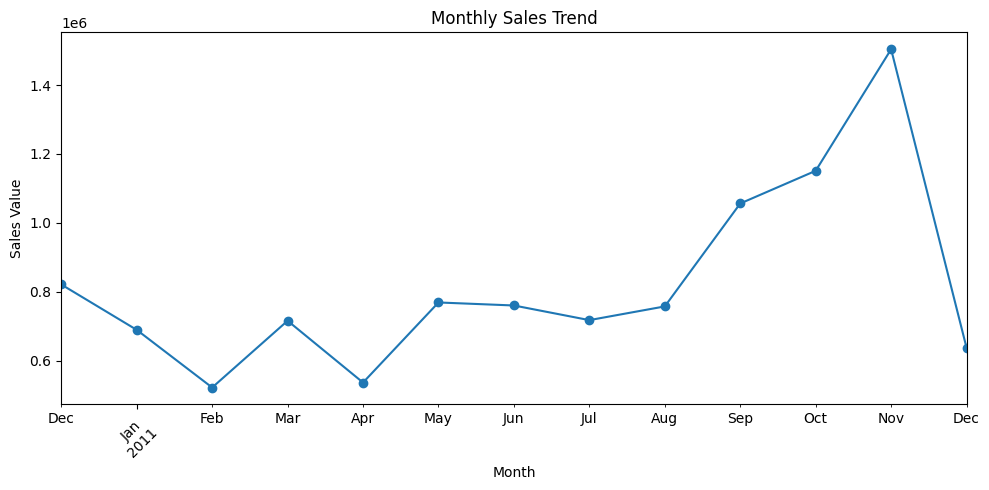

In [ ]:
monthly_sales.plot(
    kind="line",
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Sales Value",
    figsize=(10, 5),
    marker="o"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales Trend

The monthly sales analysis shows that sales varied across the study period. Sales increased strongly from September 2011 and reached the highest point in November 2011, with a sales value of **1,503,866.78**. February 2011 recorded the lowest sales value of **522,545.56**. December 2011 recorded lower sales, but this month should be interpreted carefully because the dataset only contains transactions up to December 9, 2011.

In [ ]:
product_data = analysis_df[~analysis_df["StockCode"].isin(["DOT", "M", "POST"])]

product_desc_sales = product_data.groupby("Description")["SalesValue"].sum()

top_10_products = product_desc_sales.sort_values(ascending=False).head(10)

top_10_products

,SalesValue
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


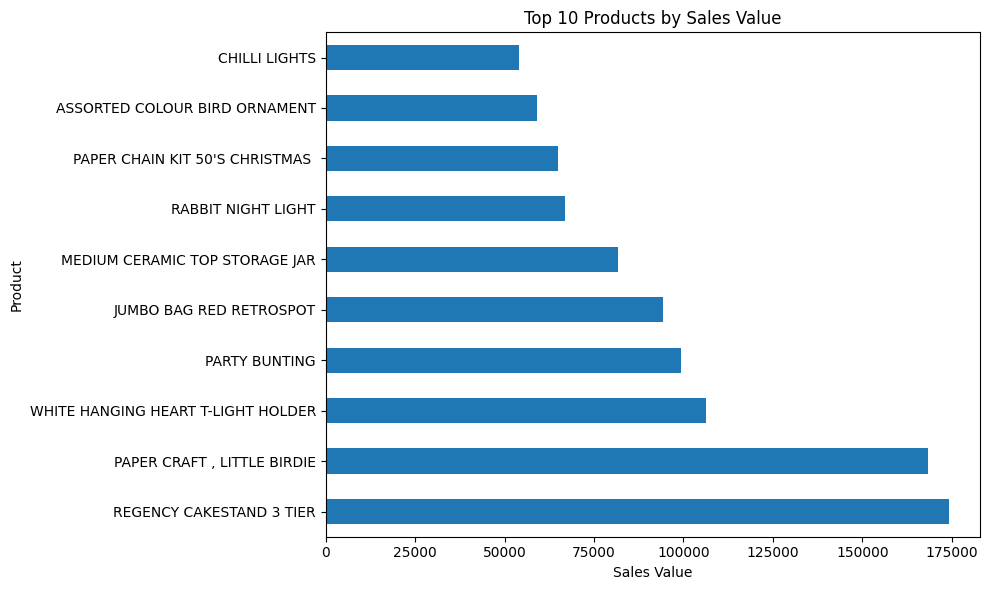

In [ ]:
top_10_products.plot(
    kind="barh",
    title="Top 10 Products by Sales Value",
    xlabel="Sales Value",
    ylabel="Product",
    figsize=(10, 6)
)

plt.tight_layout()
plt.show()

### Top 10 Products by Sales Value

The product analysis shows that REGENCY CAKESTAND 3 TIER recorded the highest sales value of 174,156.54, followed by PAPER CRAFT, LITTLE BIRDIE with 168,469.60. Other products with high sales values include WHITE HANGING HEART T-LIGHT HOLDER, PARTY BUNTING, and JUMBO BAG RED RETROSPOT. This shows that some products contributed more to the overall sales value than others.

In [ ]:
country_sales = analysis_df.groupby("Country")["SalesValue"].sum()

top_10_countries = country_sales.sort_values(ascending=False).head(10)

top_10_countries

,SalesValue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


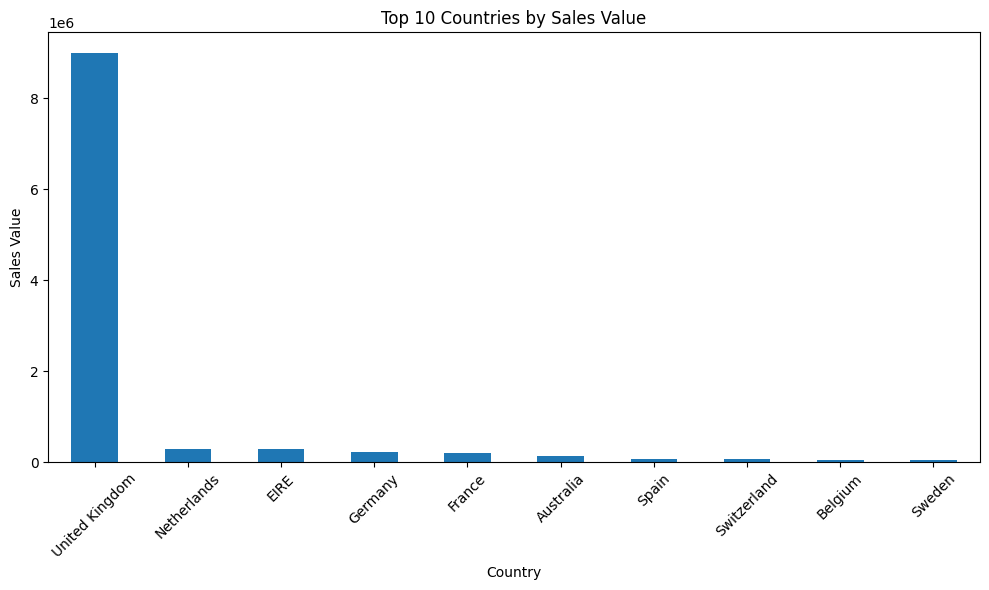

In [ ]:
top_10_countries.plot(
    kind="bar",
    figsize=(10, 6),
    title="Top 10 Countries by Sales Value"
)

plt.xlabel("Country")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Sales Performance by Country

The country analysis shows that the United Kingdom recorded the highest sales value at 9,001,744.09, which was much higher than the other countries. The Netherlands and EIRE followed with sales values of 285,446.34 and 283,140.52, respectively. Germany and France also recorded relatively high sales values. This shows that the United Kingdom was the main market in the dataset, while sales in other countries were considerably lower.

In [ ]:
total_sales = analysis_df["SalesValue"].sum()
total_quantity = analysis_df["Quantity"].sum()(np.float64(10642110.804), np.int64(5572420), 19960, 38)
$0
total_transactions = analysis_df["InvoiceNo"].nunique()
total_countries = analysis_df["Country"].nunique()

total_sales, total_quantity, total_transactions, total_countries

(np.float64(10642110.804), np.int64(5572420), 19960, 38)

In [ ]:
summary.set_index("Metric")

,Value
Metric,
Total Sales Value,"10,642,110.80"
Total Quantity Sold,"5,572,420"
Total Transactions,"19,960"
Number of Countries,38


### Overall Sales Summary

The analysis of the cleaned sales data identified a total sales value of 10,642,110.80 across 19,960 unique transactions. A total of 5,572,420 units were sold across 38 countries. These results provide an overview of the retailer's sales performance during the period covered by the dataset. The findings will be used alongside the monthly, product, and country analyses to identify sales patterns and support data-driven decision-making.

In [ ]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

highest_month, highest_sales, lowest_month, lowest_sales

(Period('2011-11', 'M'), 1503866.78, Period('2011-02', 'M'), 522545.56)

The monthly sales analysis shows that November 2011 recorded the highest sales value of 1,503,866.78, while February 2011 recorded the lowest sales value of 522,545.56. This indicates that sales performance varied during the study period. However, December's result should be interpreted carefully because the dataset only covers transactions up to December 9, 2011.

## Research Findings

The analysis revealed three important findings. First, monthly sales were not consistent throughout the study period. November 2011 recorded the highest sales value of 1,503,866.78, while February 2011 recorded the lowest at 522,545.56.

Second, REGENCY CAKESTAND 3 TIER was the highest-performing product by sales value, generating 174,156.54.

Third, the United Kingdom recorded the highest sales value among the countries analyzed, with 9,001,744.09. This was considerably higher than the sales values recorded in other countries.

These findings answer the research questions by showing how sales performance differed across months, products, and countries.


## Conclusion

This study analyzed historical sales data from the Online Retail dataset to identify sales trends and patterns that can support data-driven decision-making. The analysis examined monthly sales performance, product sales value, and sales across different countries.

The findings showed that November 2011 recorded the highest monthly sales value, while February 2011 recorded the lowest. REGENCY CAKESTAND 3 TIER recorded the highest sales value among the products analyzed, and the United Kingdom had the highest sales value among the countries examined.

Overall, the study demonstrates how historical sales data can help businesses understand their performance and identify useful patterns for decision-making.

## Recommendations

Based on the findings of this study, the following recommendations are made:

1. Businesses should monitor sales performance regularly to identify periods of high and low sales.
2. Retailers should review the performance of their products to understand which products contribute most to sales value.
3. Businesses should examine sales across different countries and markets to identify opportunities for improvement.
4. Businesses should use historical sales data to support planning, inventory management, and other sales-related decisions.
5. Future studies could include additional factors, such as customer purchasing behaviour and sales forecasting, to gain further insights into business performance.

## Data Cleaning Summary

The original dataset contained 541,909 records and 8 columns. During data preparation, missing values, duplicate records, cancelled transactions, and unusual price values were examined.

A total of 5,268 duplicate records were identified. Records with non-positive quantities or non-positive unit prices were excluded from the main sales analysis. After these cleaning steps and the removal of duplicate records, 524,878 records remained for analysis.

A new column called SalesValue was created by multiplying Quantity by UnitPrice. This column was used to calculate sales values for the monthly, product, and country analyses.

## References

Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33

